In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.cleaning import clean_data
from src.features import add_features
from src.preprocessing import create_preprocessor

In [3]:
df = pd.read_csv("../data/heart_attack_prediction_dataset.csv")

In [4]:
df = clean_data(df)

In [5]:
df = add_features(df)

In [6]:
df_processed = df.copy()

In [7]:
X = df_processed.drop(columns=["Heart Attack Risk"], axis = 1)

In [8]:
num_cols = X.select_dtypes(include = np.number).columns.tolist()
num_cols

['Age',
 'Sex',
 'Cholesterol',
 'Heart Rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Exercise Hours Per Week',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Sedentary Hours Per Day',
 'BMI',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'BP_Systolic',
 'BP_Diastolic']

In [9]:
cat_cols = X.select_dtypes(include = "object").columns.tolist()
cat_cols

['Diet']

In [10]:
preprocessor = create_preprocessor(X)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [12]:
X = df_processed.drop(columns = ["Heart Attack Risk"], axis = 1)
y = df_processed["Heart Attack Risk"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

In [14]:
preprocessor = create_preprocessor(X_train)

In [15]:
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

models = {
    "Logistic Regression": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]),

    "SVM": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', SVC(probability=True, random_state=42))
    ]),

    "KNN": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', KNeighborsClassifier(n_neighbors=5, weights='distance'))
    ]),

    "XGBoost": imbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            eval_metric='logloss',
            random_state=42
        ))
    ])
}

In [16]:
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

In [17]:
def cross_validate_models(X, y, model_dict):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "roc_auc": "roc_auc",
        "recall": "recall",
        "f2": make_scorer(fbeta_score, beta=2)
    }

    results = []

    for name, model in model_dict.items():

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        results.append({
            "Model": name,
            "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
            "Recall_mean": np.mean(scores["test_recall"]),
            "F2_mean": np.mean(scores["test_f2"])
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(by="ROC_AUC_mean", ascending=False)

In [18]:
results_df = cross_validate_models(X_train, y_train, models)
results_df

,Model,ROC_AUC_mean,Recall_mean,F2_mean
2,Random Forest,0.506114,0.104737,0.121798
5,XGBoost,0.505008,0.230191,0.247247
0,Logistic Regression,0.502024,0.478703,0.446146
3,SVM,0.491321,0.357622,0.357073
1,Decision Tree,0.487740,0.371563,0.365590
4,KNN,0.484715,0.534454,0.483950


In [19]:
param_grids = {
    "Logistic Regression": [
        {
            "model__solver": ["lbfgs"],
            "model__penalty": ["l2"],
            "model__C": [0.1, 1, 10]
        },
        {
            "model__solver": ["liblinear"],
            "model__penalty": ["l1", "l2"],
            "model__C": [0.1, 1, 10]
        },
        {
            "model__solver": ["saga"],
            "model__penalty": ["elasticnet"],
            "model__C": [0.1, 1, 10],
            "model__l1_ratio": [0.3, 0.5, 0.7]
        }
    ],

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

    "Decision Tree": {
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__ccp_alpha": [0.0, 0.001, 0.01]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale", 0.1]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.01, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'f2': make_scorer(fbeta_score, beta=2)
}

tuning_results = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=cv,
        scoring=scoring,
        refit='f2',   # optimize for F2
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    tuning_results[name] = {
        "cv_f2": grid.best_score_,
        "cv_recall": grid.cv_results_["mean_test_recall"][grid.best_index_],
        "cv_auc": grid.cv_results_["mean_test_roc_auc"][grid.best_index_],
        "best_params": grid.best_params_,
        "model": grid.best_estimator_
    }
    tuning_results[name]["model"] = best_model



🔍 Tuning Logistic Regression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

🔍 Tuning Decision Tree...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

🔍 Tuning Random Forest...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

🔍 Tuning SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

🔍 Tuning KNN...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

🔍 Tuning XGBoost...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [21]:
df_results = pd.DataFrame(tuning_results).T
df_results = df_results.sort_values("cv_recall", ascending=False)
df_results

,cv_f2,cv_recall,cv_auc,best_params,model
KNN,0.497118,0.553565,0.494368,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...","(ColumnTransformer(transformers=[('num',\n ..."
Logistic Regression,0.453021,0.487862,0.502629,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod...","(ColumnTransformer(transformers=[('num',\n ..."
Decision Tree,0.36559,0.371563,0.48774,"{'model__ccp_alpha': 0.0, 'model__max_depth': ...","(ColumnTransformer(transformers=[('num',\n ..."
SVM,0.357073,0.357622,0.491321,"{'model__C': 1, 'model__gamma': 'scale', 'mode...","(ColumnTransformer(transformers=[('num',\n ..."
XGBoost,0.185251,0.165267,0.50517,"{'model__colsample_bytree': 1.0, 'model__learn...","(ColumnTransformer(transformers=[('num',\n ..."
Random Forest,0.163132,0.143751,0.510811,"{'model__max_depth': 10, 'model__min_samples_l...","(ColumnTransformer(transformers=[('num',\n ..."


In [22]:
best_model_name = df_results.index[1]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [23]:
best_model = tuning_results[best_model_name]["model"]
best_model

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
from sklearn.metrics import roc_auc_score, classification_report, recall_score

In [25]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [26]:
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.63      0.49      0.55      1125
           1       0.35      0.49      0.41       628

    accuracy                           0.49      1753
   macro avg       0.49      0.49      0.48      1753
weighted avg       0.53      0.49      0.50      1753

ROC-AUC: 0.503518754423213


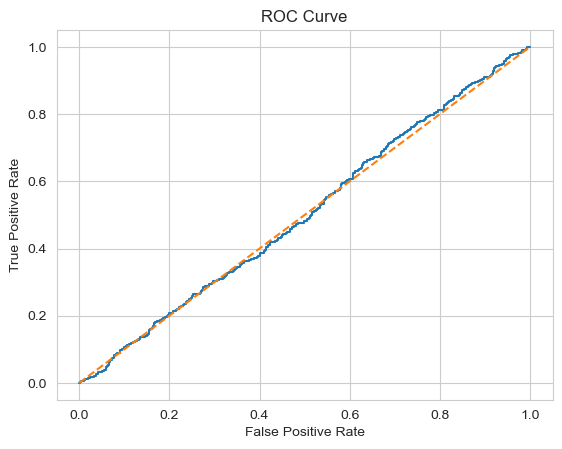

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [28]:
y_pred_custom = (y_proba >= 0.3).astype(int)

In [29]:
recall_score(y_test, y_pred_custom)

1.0

In [30]:
import joblib

joblib.dump(best_model, "../model/oldHeartAttackRisk_model.pkl")

['../model/oldHeartAttackRisk_model.pkl']

In [31]:
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

# 🔑 Handle different model types
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_

elif hasattr(model, "coef_"):
    importances = np.abs(model.coef_).flatten()  
    # absolute value → magnitude of impact

else:
    raise ValueError("Model does not support feature importance extraction")

# Build DataFrame
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Clean names
feature_importance["feature"] = feature_importance["feature"].apply(
    lambda x: x.split("__")[-1]
)

# Grouping (⚠️ careful here)
feature_importance["feature_group"] = feature_importance["feature"].apply(
    lambda x: x.split("_")[0]
)

grouped_importance = (
    feature_importance
    .groupby("feature_group")["importance"]
    .sum()
    .reset_index()
    .sort_values(by="importance", ascending=False)
)

print(grouped_importance.head(10))

          feature_group  importance
3                    BP    0.072028
16  Sleep Hours Per Day    0.047440
5              Diabetes    0.041240
4           Cholesterol    0.030375
6                  Diet    0.028780
19        Triglycerides    0.026447
15                  Sex    0.025824
11              Obesity    0.025298
0                   Age    0.023636
18         Stress Level    0.021624


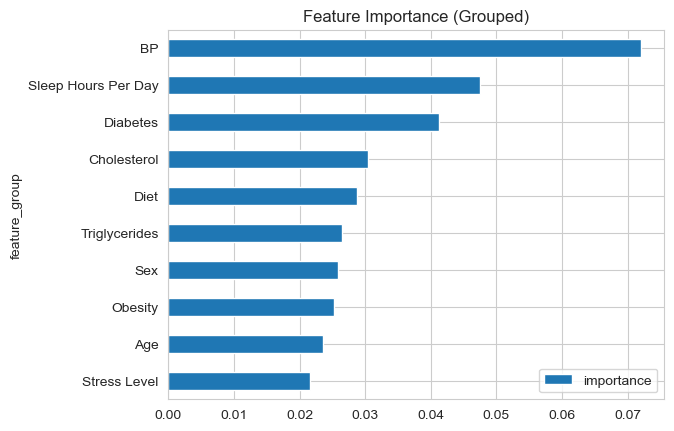

In [32]:
grouped_importance.head(10).plot(
    kind="barh",
    x="feature_group",
    y="importance"
)

plt.gca().invert_yaxis()
plt.title("Feature Importance (Grouped)")
plt.show()